# Инференс на тесте и трёх винах eval: ошибки и важность признаков

**Что здесь.** Нынешняя конфигурация сервиса прогоняется по двум наборам кадров:

- **тест** — изолированный holdout `data/test` (живые и свои кадры): знакомые вина каталога
  и незнакомые;
- **eval: 3 вина** — контрольные фото организатора `data/eval/queries` (одно знакомое —
  Массандра «Мускатель белый», два незнакомых — Tabiya Пино Нуар и Aristov Donum).

Для каждого — итог, где теряется верное вино, галерея ошибок и что решало: глобальная
важность признаков CatBoost и SHAP на реальных кадрах.

**Конфигурация** — как в eval-ручке `/v1/eval/predict`: `index_platform_sq_v3`,
`decider_platform_sq_v3_slug` (порог 0.48), guard `warn`, VLM-судья family-verify со сверкой
выбора по тексту (`WINE_VLM_CHECK=1`). Два режима ответа:

- **режим заказчика** — ответ всегда top-1 (так работает `/v1/eval/predict`): для знакомых
  вин это главная метрика;
- **продуктовый** — ответ только выше порога: для незнакомых вин важно, чтобы был отказ.

«Без судьи» восстанавливается из отчёта судьи (`before_id`), отдельный прогон не нужен.

Тест — только измерение: ничего по нему не подбирается.

In [1]:
from pathlib import Path
import hashlib, json, os, pickle, sys, textwrap, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path[:0] = [str(ROOT), str(ROOT / 'eval')]

INDEX = Path('models/index_platform_sq_v3')
DECIDER = Path('models/decider_platform_sq_v3_slug')
CACHE = Path('data/derived/nb08')
CROPS = CACHE / 'crops'
RESULTS = CACHE / 'inference.pkl'
# True (или NB08_RERUN=1) — прогнать инференс заново (≈10 минут; судье нужны ключи Yandex).
RERUN = os.environ.get('NB08_RERUN') == '1'

# Палитра: статусы — для исходов (всегда с подписью), категориальные слоты — для групп
# признаков, синий↔красный — для знака вклада SHAP.
SURFACE, INK, INK2, MUTED, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#8d8c86', '#e7e6e1'
GOOD, SERIOUS, CRITICAL, NEUTRAL = '#0ca30c', '#ec835a', '#d03b3b', '#c9c8c2'
BLUE, ORANGE, AQUA, YELLOW, VIOLET = '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7'
POS, NEG = '#2a78d6', '#e34948'
RAMP = ['#b7d3f6', '#86b6ef', '#5598e7', '#2a78d6', '#1c5cab', '#104281']
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#cde2fb', '#6da7ec', '#256abf', '#0d366b'])

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'xtick.color': INK2, 'ytick.color': INK2, 'text.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'font.size': 10, 'legend.frameon': False, 'figure.dpi': 110,
})

OUTCOME_COLORS = {
    'верно': GOOD, 'близнец той же винодельни': SERIOUS, 'чужая винодельня': CRITICAL,
    'верный отказ': GOOD, 'ложный приём': CRITICAL,
}


def status_strip(ax, color, width=5):
    """Цветная рамка кадра — исход; подпись всегда рядом текстом."""
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color(color); spine.set_linewidth(width)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)


def wrap(text, width=48, lines=4):
    text = ' '.join(str(text or '').split())
    return '\n'.join(textwrap.wrap(text, width)[:lines]) or '—'

## 1. Инференс

Кадр → `WineScanner.identify(trace=True)` → исход через `eval/platform_benchmark.evaluate`
(те же правила, что в бенчмарке). Для каждого кадра сохраняются первые 8 кандидатов, верная
карточка и лидер до судьи вместе с их признаками — по ним ниже считается SHAP.

In [2]:
KEEP = 8


def load_env(path=Path('.env')):
    if not path.exists():
        return
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            key, value = line.split('=', 1)
            os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))


def run_inference():
    from tqdm.auto import tqdm
    from wine_scanner.catalog import TEST_MANIFEST, load_manifest
    from wine_scanner.embed import load_image
    from wine_scanner.pipeline import WineScanner
    from platform_benchmark import CROP_CACHE, evaluate

    load_env()
    os.environ['WINE_VLM'] = '1'
    scanner = WineScanner(index_dir=INDEX, decider_dir=DECIDER, crop_cache=CROP_CACHE,
                          ocr_cache=True)
    queries = [q for q in load_manifest(TEST_MANIFEST) if q.source in {'live', 'own', 'eval'}]
    CROPS.mkdir(parents=True, exist_ok=True)
    records = []
    for query in tqdm(queries, desc='инференс'):
        key = str(query.path)
        image = load_image(query.path)
        result = scanner.identify(image, image_key=key, trace=True, use_judge=True)
        out = evaluate(scanner, query, result)
        thumb = CROPS / (hashlib.sha1(key.encode()).hexdigest()[:16] + '.jpg')
        crop = scanner._crop(image, key).convert('RGB')
        crop.thumbnail((520, 520))
        crop.save(thumb, quality=88)

        judge = result.judge or {}
        best_id = result.best.item_id if result.best else ''
        before_id = judge.get('before_id') or best_id
        position = {c.item_id: i for i, c in enumerate(result.candidates)}
        wanted = [c.item_id for c in result.candidates[:KEEP]]
        wanted += [i for i in dict.fromkeys([query.true_id, before_id]) if i and i not in wanted]
        candidates = [
            {'item_id': i, 'rank': position[i],
             'probability': result.candidates[position[i]].probability,
             'features': dict(result.candidates[position[i]].features)}
            for i in wanted if i in position
        ]
        records.append({
            'path': key, 'wine_id': query.wine_id, 'true_id': query.true_id,
            'known': query.known, 'group': query.group, 'source': query.source,
            'note': query.note, 'vis_rank': out.vis_rank, 'txt_rank': out.txt_rank,
            'in_long_list': out.in_long_list, 'in_window': out.in_window,
            'best_id': best_id, 'probability': out.probability, 'answered': result.answered,
            'guard': result.guard, 'judge': result.judge, 'before_id': before_id,
            'before_probability': judge.get('before_probability', out.probability),
            'before_answered': judge.get('before_answered', result.answered),
            'ocr_lines': list((result.trace or {}).get('ocr_lines', [])),
            'total_s': result.timings.get('total', float('nan')),
            'thumb': str(thumb), 'candidates': candidates,
        })
    meta = {'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
            'judge': scanner.judge is not None,
            'judge_check': getattr(scanner.judge, 'check', None),
            'threshold': scanner.threshold, 'frames': len(records)}
    CACHE.mkdir(parents=True, exist_ok=True)
    with RESULTS.open('wb') as fh:
        pickle.dump({'records': records, 'meta': meta}, fh)


if RERUN or not RESULTS.exists():
    run_inference()
with RESULTS.open('rb') as fh:
    DATA = pickle.load(fh)
RECORDS, META = DATA['records'], DATA['meta']
print(META)

{'timestamp': '2026-09-25T11:45:18', 'judge': True, 'judge_check': True, 'threshold': 0.48, 'frames': 195}


In [3]:
from catboost import CatBoostClassifier, Pool
from wine_scanner.catalog import load_equivalences
from wine_scanner.index import VectorIndex

EQ = load_equivalences()
_index = VectorIndex.load(INDEX)
PAYLOAD = dict(zip(_index.item_ids, _index.payloads))
THRESHOLD = META['threshold']


def card_name(item_id, width=34):
    p = PAYLOAD.get(item_id)
    if not p:
        return 'нет в каталоге'
    return wrap(f"{p.get('winery', '')} · {p.get('name', '')}", width, 3)


def card_image(item_id):
    p = PAYLOAD.get(item_id) or {}
    path = Path(str(p.get('image_path', '')).replace('\\', '/'))
    if path.is_file():
        image = Image.open(path).convert('RGB'); image.thumbnail((360, 360)); return image
    return None


def verdict(true_id, best_id, known):
    if not known:
        return 'незнакомое'
    if EQ.same(true_id, best_id):
        return 'верно'
    same = PAYLOAD.get(true_id, {}).get('winery') == PAYLOAD.get(best_id, {}).get('winery')
    return 'близнец той же винодельни' if same else 'чужая винодельня'


MODEL = CatBoostClassifier()
MODEL.load_model(str(DECIDER / 'model.cbm'))
NAMES = json.loads((DECIDER / 'meta.json').read_text(encoding='utf-8'))['feature_names']


def logits(features_list):
    matrix = np.asarray([[float(f.get(n, 0.0)) for n in NAMES] for f in features_list])
    return MODEL.predict(matrix, prediction_type='RawFormulaVal')


# Три шага выбора: решающий слой (максимум логита) → правило семьи и защита (лидер, которого
# увидел судья, `before_id`) → судья (`best_id`).
for record in RECORDS:
    cands = record['candidates']
    record['decider_id'] = cands[int(np.argmax(logits([c['features'] for c in cands])))]['item_id']

F = pd.DataFrame([{k: v for k, v in r.items() if k != 'candidates'} for r in RECORDS])
F['part'] = np.where(F.source == 'eval', 'eval', 'тест')
F['after'] = [verdict(t, b, k) for t, b, k in zip(F.true_id, F.best_id, F.known)]
F['before'] = [verdict(t, b, k) for t, b, k in zip(F.true_id, F.before_id, F.known)]
F['decider'] = [verdict(t, b, k) for t, b, k in zip(F.true_id, F.decider_id, F.known)]
F['applied'] = F.judge.map(lambda j: (j or {}).get('applied') or 'не звали')
F['read_text'] = F.judge.map(lambda j: (j or {}).get('read_text') or '')
F['unknown_after'] = np.where(F.answered, 'ложный приём', 'верный отказ')
F['unknown_before'] = np.where(F.before_answered, 'ложный приём', 'верный отказ')
T, E = F[F.part == 'тест'], F[F.part == 'eval']
print(f"тест: {len(T)} кадров ({T.known.sum()} знакомых, {(~T.known).sum()} незнакомых); "
      f"eval: {len(E)} кадра ({E.known.sum()} знакомый); судья: {META['judge']}, "
      f"сверка: {META['judge_check']}")

тест: 192 кадров (92 знакомых, 100 незнакомых); eval: 3 кадра (1 знакомый); судья: True, сверка: True


## 2. Итог одним взглядом

Слева — знакомые вина теста в режиме заказчика (ответ всегда top-1): без судьи и с судьёй.
Справа — незнакомые вина в продуктовом режиме: ответ выше порога — это ложный приём.

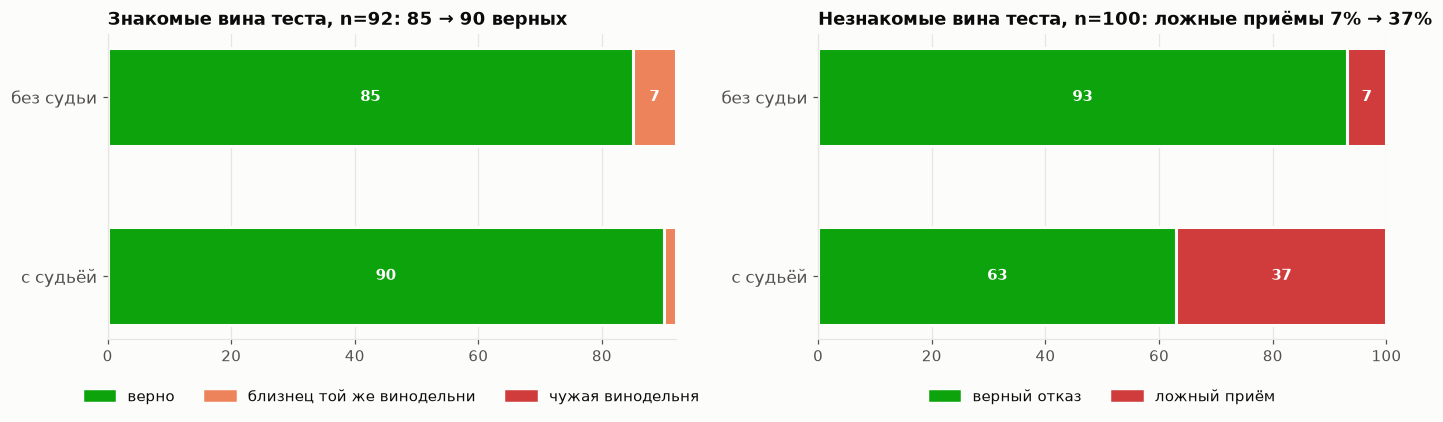

In [4]:
KNOWN_ORDER = ['верно', 'близнец той же винодельни', 'чужая винодельня']
UNKNOWN_ORDER = ['верный отказ', 'ложный приём']


def stacked(ax, rows, order, title, total):
    y = np.arange(len(rows))[::-1]
    for yi, (label, counts) in zip(y, rows):
        left = 0
        for name in order:
            value = counts.get(name, 0)
            if value:
                ax.barh(yi, value, left=left, color=OUTCOME_COLORS[name], height=0.55,
                        edgecolor=SURFACE, linewidth=2)
                if value / total > 0.06:
                    ax.text(left + value / 2, yi, str(value), ha='center', va='center',
                            color='white', fontweight='bold')
                left += value
    ax.set_yticks(y, [label for label, _ in rows], fontsize=11)
    ax.set_xlim(0, total); ax.grid(axis='y', visible=False)
    ax.set_title(title)
    handles = [plt.Rectangle((0, 0), 1, 1, color=OUTCOME_COLORS[n]) for n in order]
    ax.legend(handles, order, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=len(order))


known, unknown = T[T.known], T[~T.known]
fig, axes = plt.subplots(1, 2, figsize=(15, 3.6), gridspec_kw={'wspace': 0.25})
stacked(axes[0], [('без судьи', known.before.value_counts()),
                  ('с судьёй', known.after.value_counts())], KNOWN_ORDER,
        f'Знакомые вина теста, n={len(known)}: '
        f'{(known.before == "верно").sum()} → {(known.after == "верно").sum()} верных',
        len(known))
stacked(axes[1], [('без судьи', unknown.unknown_before.value_counts()),
                  ('с судьёй', unknown.unknown_after.value_counts())], UNKNOWN_ORDER,
        f'Незнакомые вина теста, n={len(unknown)}: ложные приёмы '
        f'{(unknown.unknown_before == "ложный приём").mean():.0%} → '
        f'{(unknown.unknown_after == "ложный приём").mean():.0%}', len(unknown))
plt.show()

Три вина eval — каждое отдельной карточкой: кадр, ответ сервиса и исход. Рамка — исход
(зелёная — верно / верный отказ, красная — ошибка), подпись под кадром.

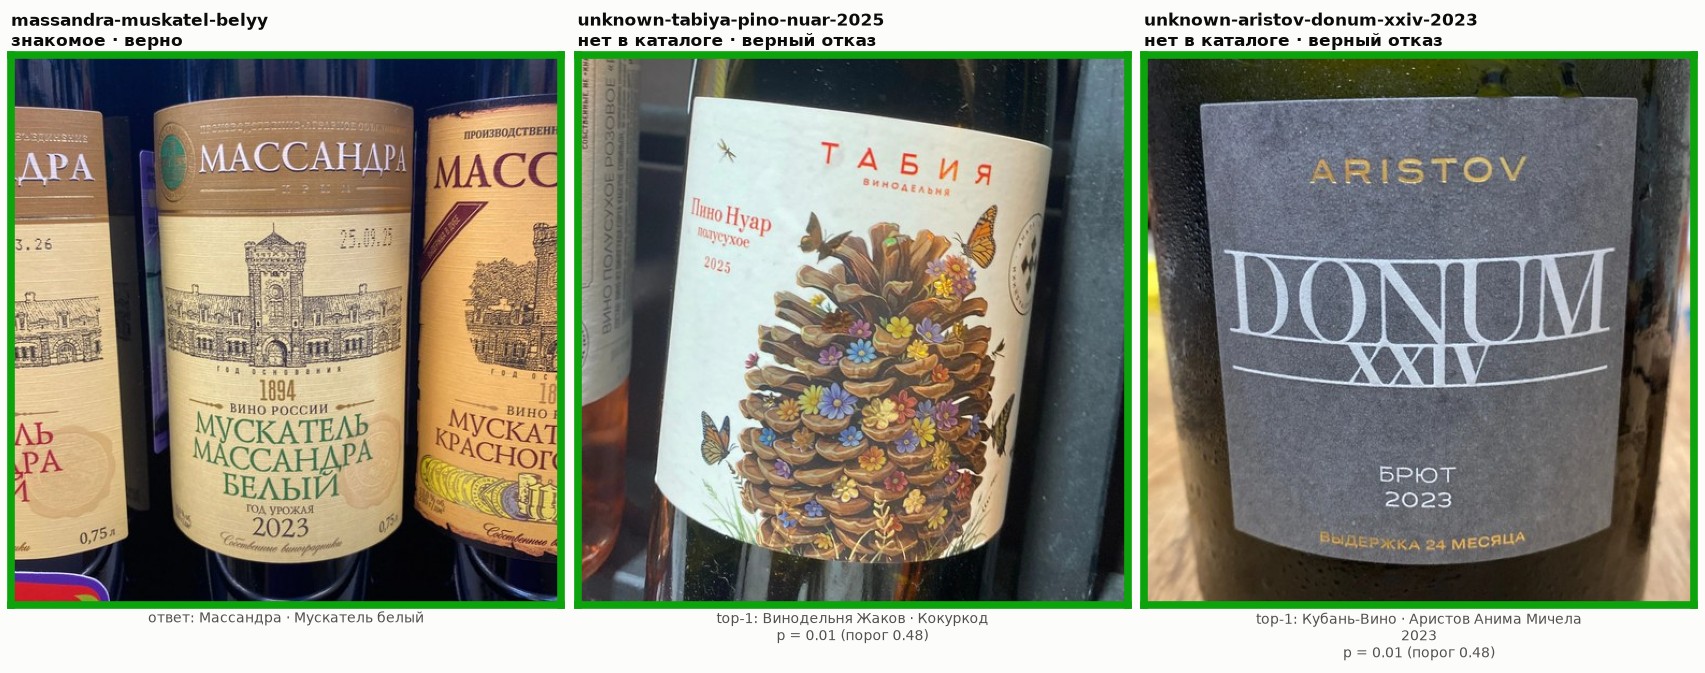

In [5]:
fig, axes = plt.subplots(1, len(E), figsize=(5.2 * len(E), 6.2))
for ax, (_, row) in zip(np.atleast_1d(axes), E.iterrows()):
    ax.imshow(Image.open(row.thumb))
    if row.known:
        outcome = row.after
        detail = f'ответ: {card_name(row.best_id)}'
    else:
        outcome = row.unknown_after
        detail = (f'top-1: {card_name(row.best_id)}\np = {row.probability:.2f} '
                  f'(порог {THRESHOLD:.2f})')
    status_strip(ax, OUTCOME_COLORS.get(outcome, NEUTRAL))
    kind = 'знакомое' if row.known else 'нет в каталоге'
    ax.set_title(f'{row.wine_id[:38]}\n{kind} · {outcome}', fontsize=11)
    ax.set_xlabel(detail, fontsize=9, color=INK2)
plt.tight_layout(); plt.show()

## 3. Где теряется верное вино (знакомые вина теста)

Верная карточка должна попасть в длинный список (FAISS + текст + родня по винодельне), затем
в окно геометрии, затем стать первой у решающего слоя (CatBoost). Дальше два шага могут
переставить лидера: правило семьи (`sibling_swap`, текст этикетки против соседки по линейке)
и VLM-судья. Последние два шага могут и добавить верных, поэтому это не строгая воронка.

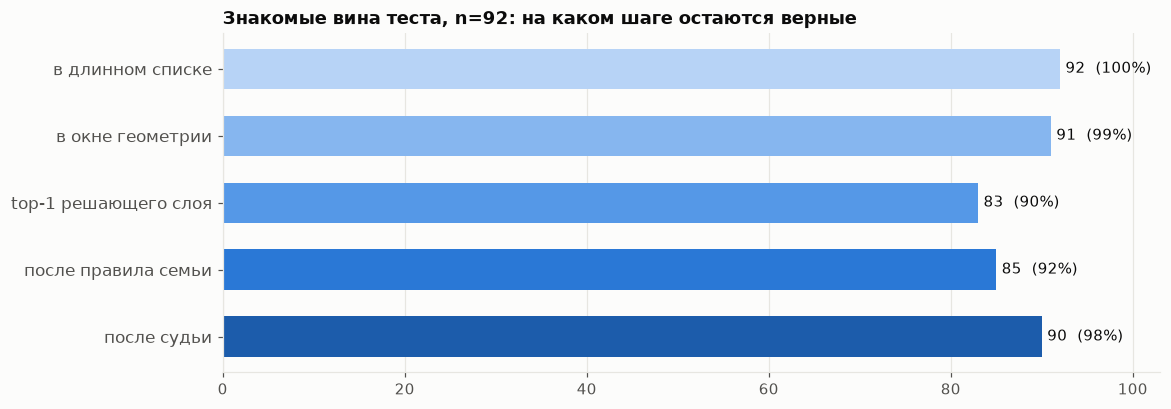

ошибки после судьи: 2 | из них близнецы той же винодельни: 2


In [6]:
stages = [
    ('в длинном списке', known.in_long_list.sum()),
    ('в окне геометрии', known.in_window.sum()),
    ('top-1 решающего слоя', (known.decider == 'верно').sum()),
    ('после правила семьи', (known.before == 'верно').sum()),
    ('после судьи', (known.after == 'верно').sum()),
]
fig, ax = plt.subplots(figsize=(11, 4))
y = np.arange(len(stages))[::-1]
for yi, (label, value), color in zip(y, stages, RAMP):
    ax.barh(yi, value, color=color, height=0.6)
    ax.text(value + 0.6, yi, f'{value}  ({value / len(known):.0%})', va='center', color=INK)
ax.set_yticks(y, [s[0] for s in stages], fontsize=11)
ax.set_xlim(0, len(known) * 1.12); ax.grid(axis='y', visible=False)
ax.set_title(f'Знакомые вина теста, n={len(known)}: на каком шаге остаются верные')
plt.show()

errors = known[known.after != 'верно']
print('ошибки после судьи:', len(errors), '| из них близнецы той же винодельни:',
      (errors.after == 'близнец той же винодельни').sum())

### 3.1 Галерея ошибок теста

Каждая строка — одна ошибка: кадр, что ответил сервис, какая карточка верная. Под кадром —
что прочитал судья и его действие; под карточками — текстовые сигналы (цвет, сорт, сладость:
+1 сходится, −1 противоречит, 0 не с чем сравнить; `disc` — доля различающих слов).

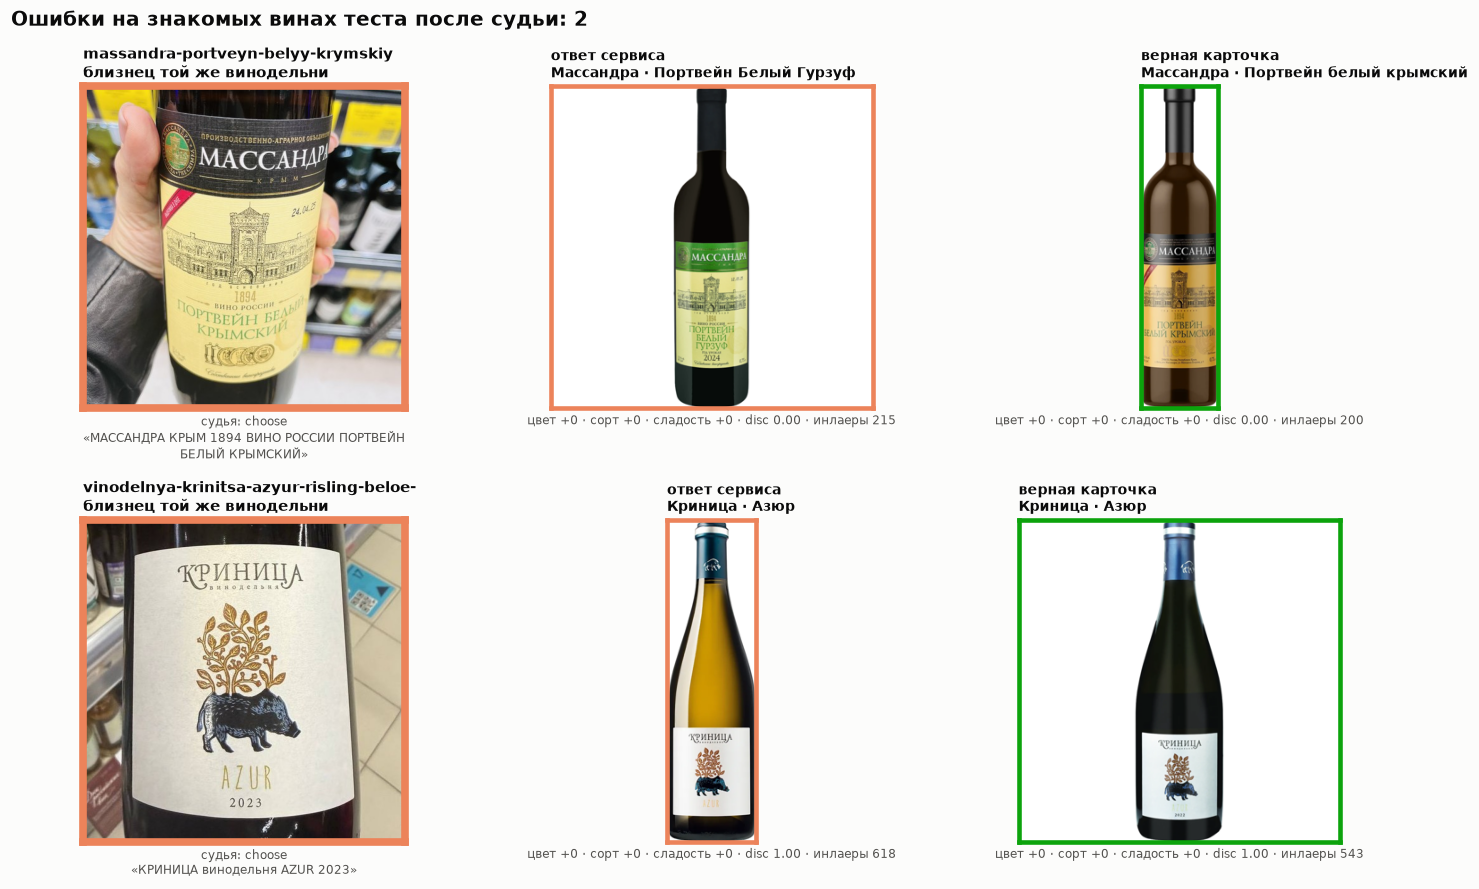

In [7]:
def features_of(record, item_id):
    for cand in record['candidates']:
        if cand['item_id'] == item_id:
            return cand['features']
    return {}


def signals_line(f):
    if not f:
        return 'нет в списке кандидатов'
    return (f"цвет {f.get('color_match', 0):+d} · сорт {f.get('grape_match', 0):+d} · "
            f"сладость {f.get('style_match', 0):+d} · disc {f.get('disc_hit', 0):.2f} · "
            f"инлаеры {f.get('inliers', 0)}")


BY_PATH = {r['path']: r for r in RECORDS}


def error_gallery(frame, title):
    if frame.empty:
        print('ошибок нет'); return
    fig, axes = plt.subplots(len(frame), 3, figsize=(13, 4.1 * len(frame)), squeeze=False)
    fig.suptitle(title, x=0.01, ha='left', fontsize=13, fontweight='bold')
    for row_axes, (_, row) in zip(axes, frame.iterrows()):
        record = BY_PATH[row.path]
        color = OUTCOME_COLORS.get(row.after, NEUTRAL)
        a0, a1, a2 = row_axes
        a0.imshow(Image.open(row.thumb)); status_strip(a0, color)
        a0.set_title(f'{row.wine_id[:40]}\n{row.after}', fontsize=10)
        a0.set_xlabel(f'судья: {row.applied}\n«{wrap(row.read_text, 44, 3)}»', fontsize=8,
                      color=INK2)
        for ax, item_id, label, frame_color in ((a1, row.best_id, 'ответ сервиса', color),
                                                (a2, row.true_id, 'верная карточка', GOOD)):
            image = card_image(item_id)
            if image is not None:
                ax.imshow(image)
            status_strip(ax, frame_color, 3)
            ax.set_title(f'{label}\n{card_name(item_id, 40)}', fontsize=9)
            ax.set_xlabel(signals_line(features_of(record, item_id)), fontsize=8, color=INK2)
    plt.tight_layout(); plt.show()


error_gallery(errors, f'Ошибки на знакомых винах теста после судьи: {len(errors)}')

### 3.2 Что поменял судья

Кадры, где верность ответа до и после судьи разная: «исправил» — было неверно, стало верно;
«сломал» — наоборот. Для незнакомых вин судья в продуктовом режиме может поднять вероятность
выше порога — это видно в разделе 4.

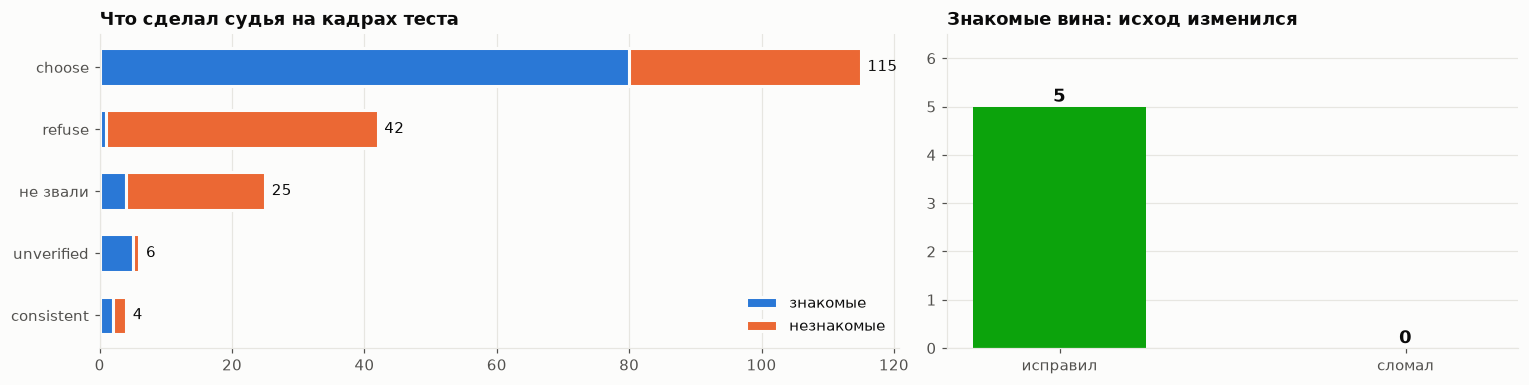

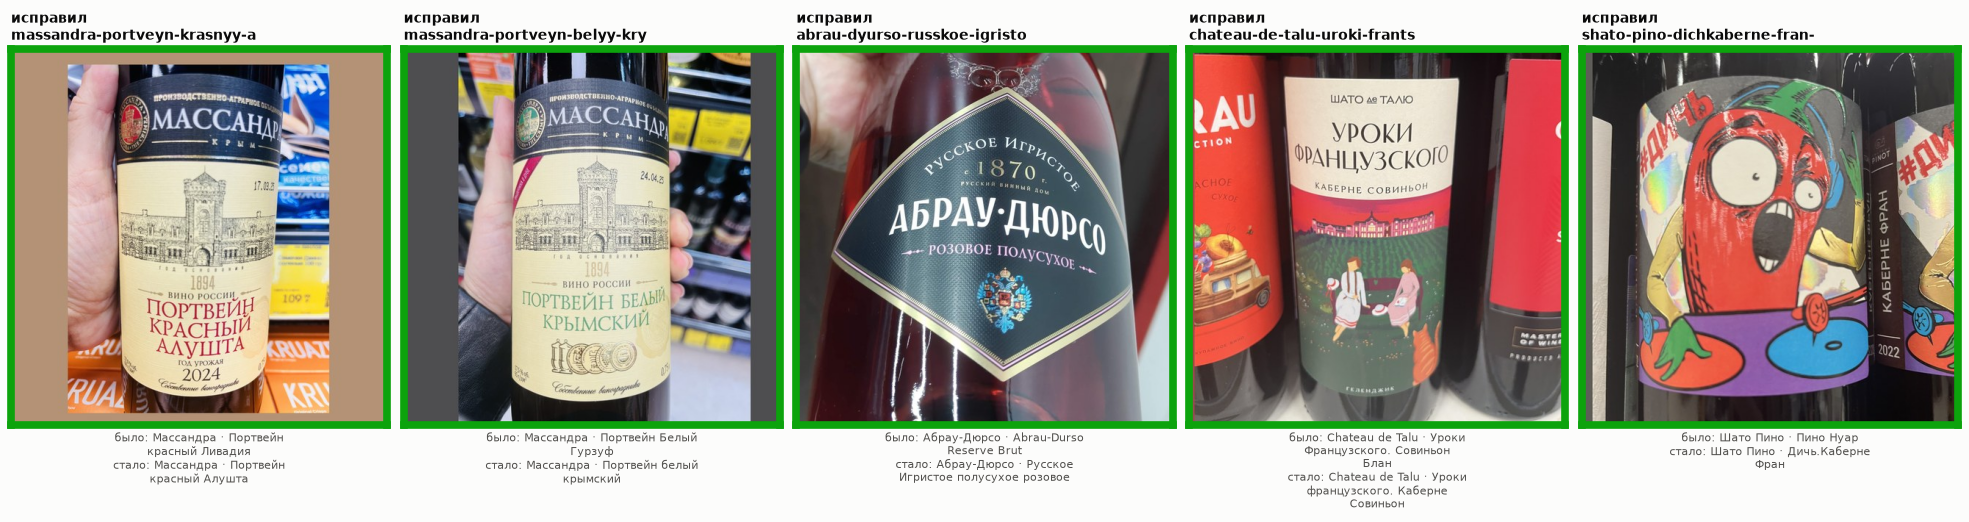

In [8]:
changed = known[(known.before == 'верно') != (known.after == 'верно')].copy()
changed['effect'] = np.where(changed.after == 'верно', 'исправил', 'сломал')
applied = T.groupby(['known', 'applied']).size().unstack(0).fillna(0).astype(int)
applied.columns = ['незнакомые' if not c else 'знакомые' for c in applied.columns]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 3.6), gridspec_kw={'width_ratios': [1.4, 1]})
order = applied.sum(axis=1).sort_values().index
bottom = np.zeros(len(order))
for name, color in (('знакомые', BLUE), ('незнакомые', ORANGE)):
    if name in applied:
        values = applied.loc[order, name].to_numpy()
        ax0.barh(order, values, left=bottom, color=color, height=0.6, label=name,
                 edgecolor=SURFACE, linewidth=2)
        bottom += values
for yi, total in enumerate(bottom):
    ax0.text(total + 1, yi, str(int(total)), va='center')
ax0.grid(axis='y', visible=False); ax0.legend(loc='lower right')
ax0.set_title('Что сделал судья на кадрах теста')
effects = changed.effect.value_counts().reindex(['исправил', 'сломал']).fillna(0).astype(int)
ax1.bar(effects.index, effects.values, color=[GOOD, CRITICAL], width=0.5)
for xi, value in enumerate(effects.values):
    ax1.text(xi, value + 0.1, str(value), ha='center', fontsize=12, fontweight='bold')
ax1.grid(axis='x', visible=False); ax1.set_ylim(0, max(effects.max(), 1) * 1.3)
ax1.set_title('Знакомые вина: исход изменился')
plt.tight_layout(); plt.show()

if not changed.empty:
    fig, axes = plt.subplots(1, len(changed), figsize=(3.6 * len(changed), 4.6), squeeze=False)
    for ax, (_, row) in zip(axes[0], changed.iterrows()):
        ax.imshow(Image.open(row.thumb))
        status_strip(ax, GOOD if row.effect == 'исправил' else CRITICAL)
        ax.set_title(f'{row.effect}\n{row.wine_id[:28]}', fontsize=9)
        ax.set_xlabel(f'было: {card_name(row.before_id, 26)}\nстало: {card_name(row.best_id, 26)}',
                      fontsize=7, color=INK2)
    plt.tight_layout(); plt.show()

## 4. Знакомые против незнакомых: уверенность top-1

Каждая точка — кадр; по горизонтали — калиброванная вероятность лучшего кандидата, линия —
продуктовый порог. Всё правее порога — ответ; для незнакомых вин это ложный приём. Крупные
точки с подписью — три вина eval. Слева — до судьи, справа — после.

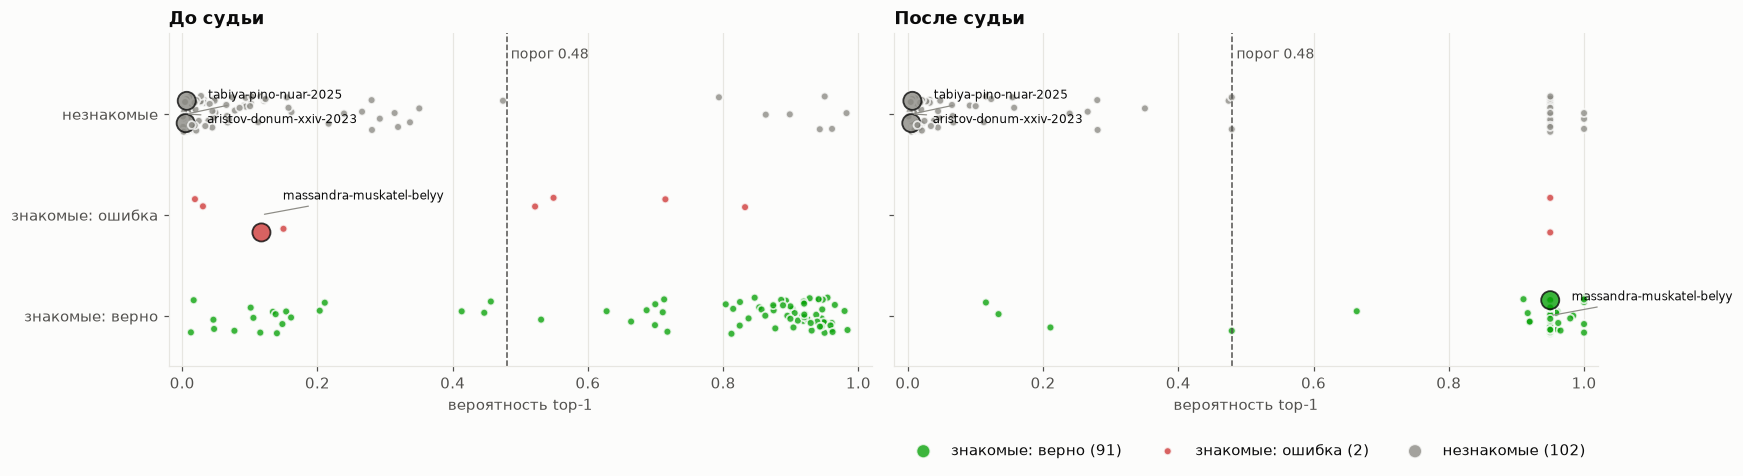

In [9]:
def cloud(ax, frame, column, title):
    groups = [
        ('знакомые: верно', frame.known & (frame[column + '_v'] == 'верно'), GOOD),
        ('знакомые: ошибка', frame.known & (frame[column + '_v'] != 'верно'), CRITICAL),
        ('незнакомые', ~frame.known, MUTED),
    ]
    rng = np.random.default_rng(0)
    for yi, (label, mask, color) in enumerate(groups):
        sub = frame[mask]
        jitter = rng.uniform(-0.18, 0.18, len(sub))
        size = np.where(sub.part == 'eval', 140, 26)
        ax.scatter(sub[column], yi + jitter, s=size, color=color, alpha=0.8,
                   edgecolor=np.where(sub.part == 'eval', INK, SURFACE), linewidth=1.2,
                   label=f'{label} ({len(sub)})')
        for k, (_, row) in enumerate(sub[sub.part == 'eval'].iterrows()):
            ax.annotate(row.wine_id.replace('unknown-', '')[:26], (row[column], yi),
                        xytext=(14, 10 - 16 * k), textcoords='offset points', fontsize=8,
                        color=INK, arrowprops={'arrowstyle': '-', 'color': MUTED, 'lw': 0.8})
    ax.axvline(THRESHOLD, color=INK2, linestyle='--', linewidth=1)
    ax.text(THRESHOLD, 2.55, f' порог {THRESHOLD:.2f}', color=INK2, fontsize=9)
    ax.set_yticks(range(3), [g[0] for g in groups]); ax.set_ylim(-0.5, 2.8)
    ax.set_xlim(-0.02, 1.02); ax.set_xlabel('вероятность top-1'); ax.set_title(title)
    ax.grid(axis='y', visible=False)


G = F.assign(before_v=F.before, probability_v=F.after)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.6), sharey=True)
cloud(axes[0], G.rename(columns={'before_probability': 'before_p'}).assign(
    before_p_v=G.before), 'before_p', 'До судьи')
cloud(axes[1], G, 'probability', 'После судьи')
axes[1].legend(loc='lower left', bbox_to_anchor=(0, -0.32), ncol=3)
plt.tight_layout(); plt.show()

## 5. Три вина eval крупно

Для каждого фото: кадр, первые кандидаты с вероятностями (рамка у верной карточки — зелёная),
что прочитали PaddleOCR и судья, и **почему решающий слой поставил первым именно этого
кандидата** — вклады признаков SHAP в логит модели: синие толкают к «это верная карточка»,
красные — против.

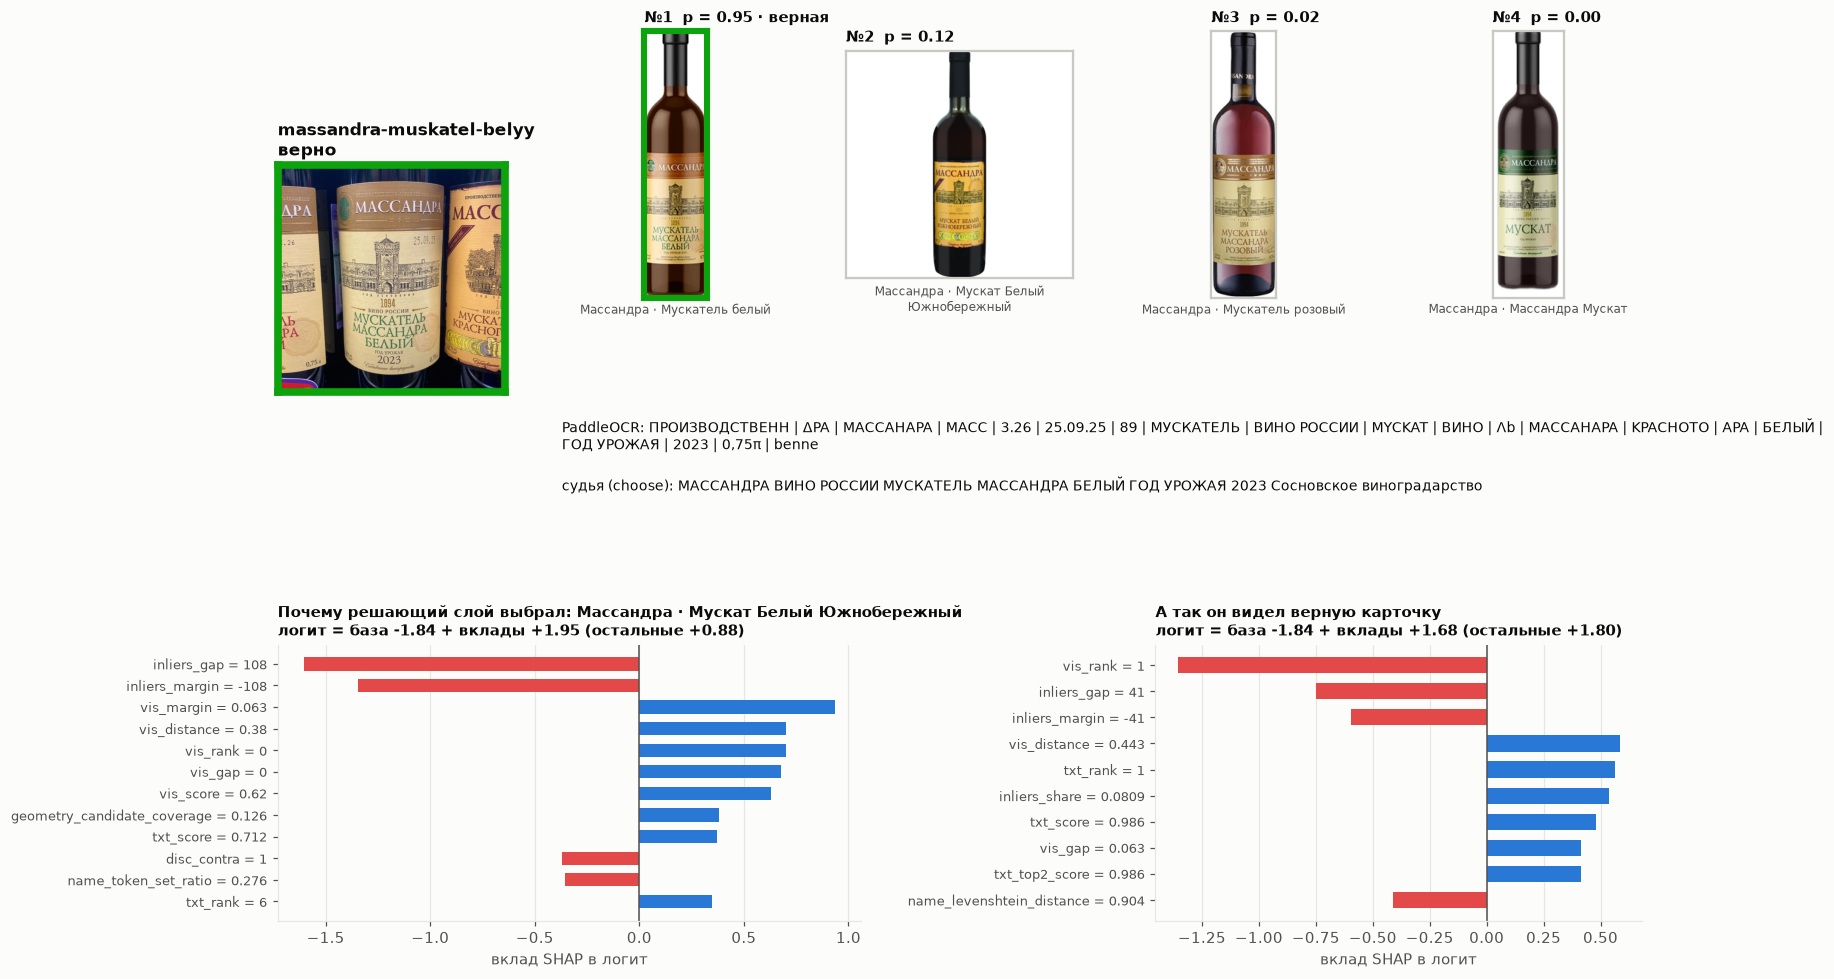

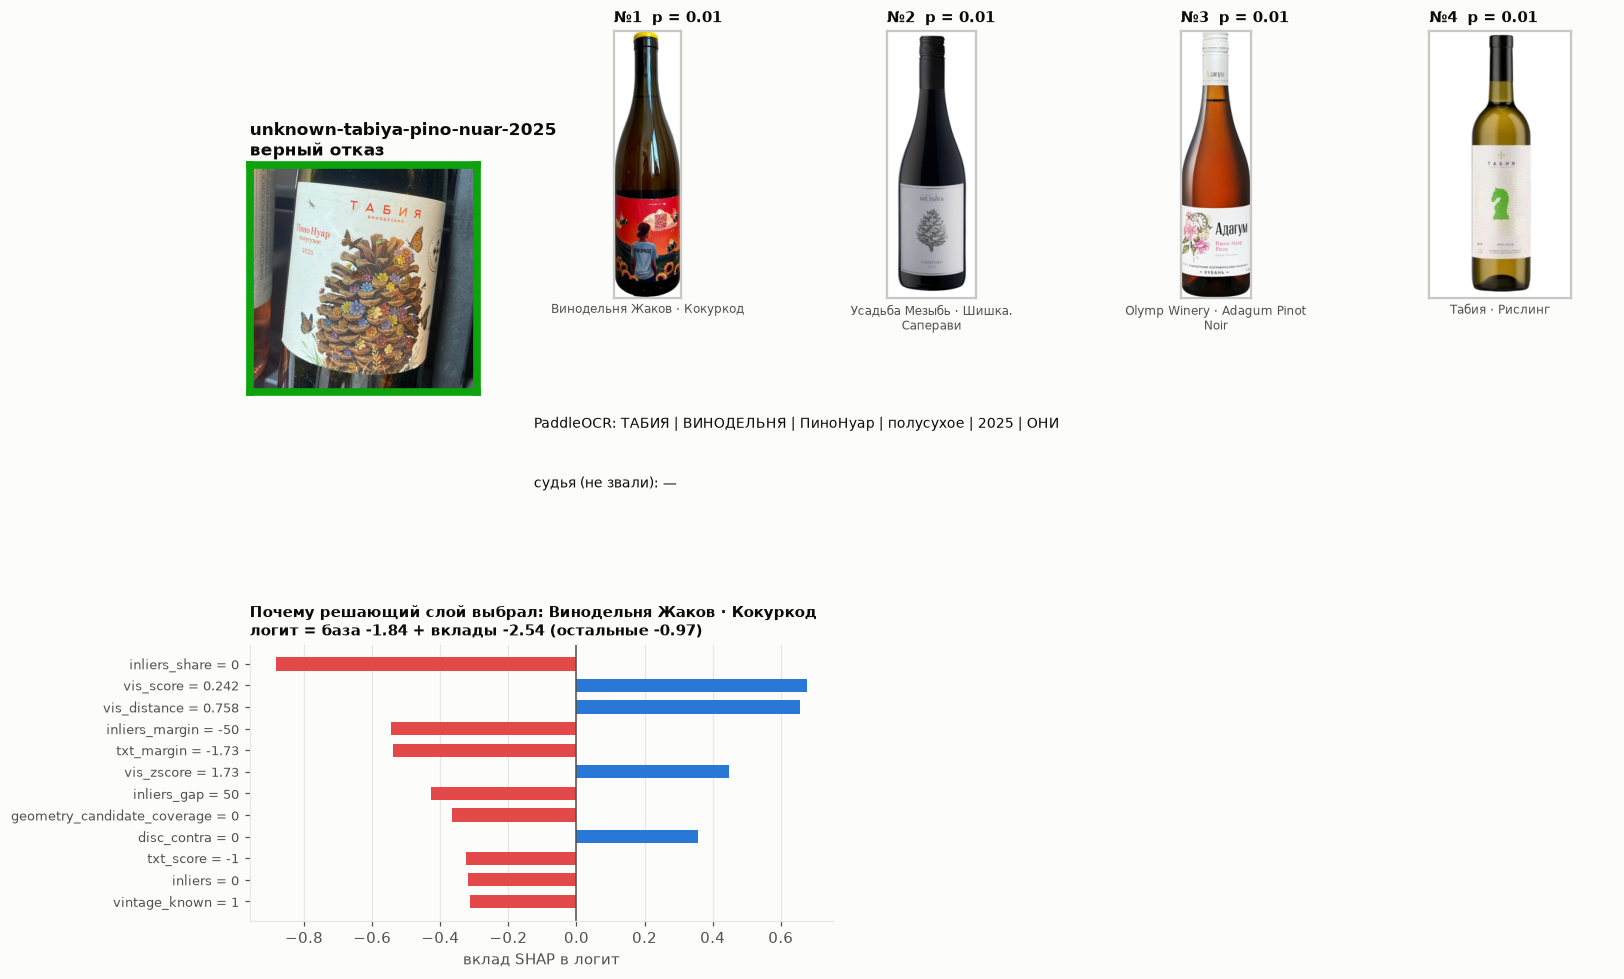

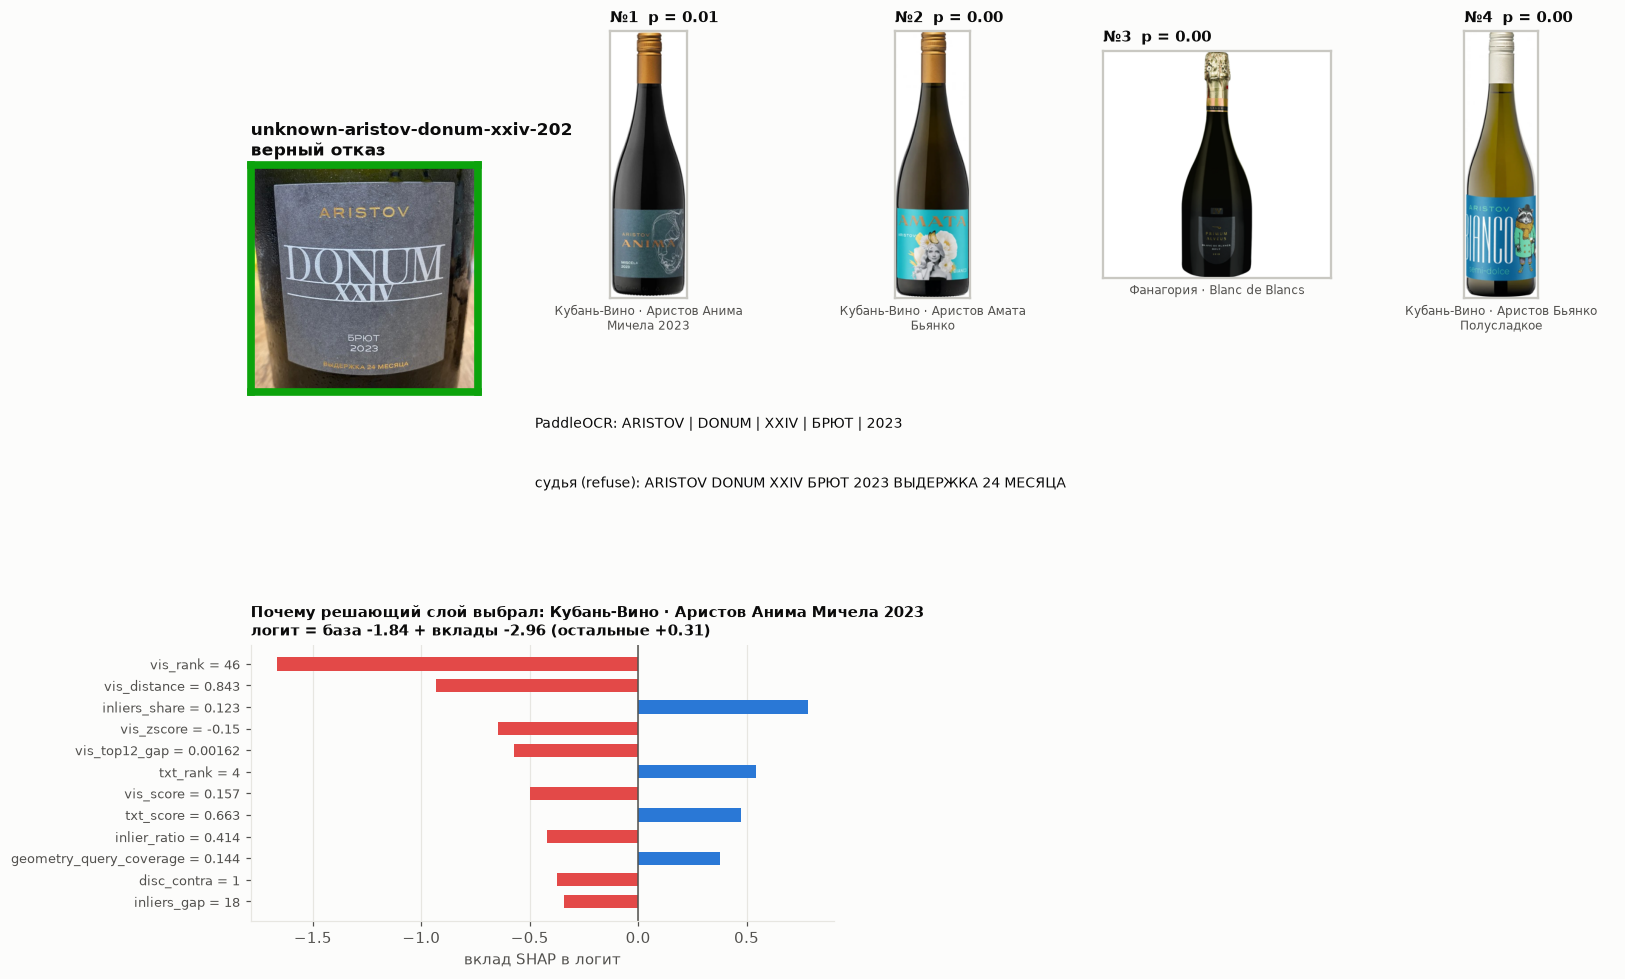

In [10]:
def shap_rows(features_list):
    matrix = np.asarray([[float(f.get(n, 0.0)) for n in NAMES] for f in features_list])
    values = MODEL.get_feature_importance(Pool(matrix), type='ShapValues')
    return matrix, values[:, :-1], values[:, -1]


def waterfall(ax, features, title, top=12):
    matrix, shap, base = shap_rows([features])
    contrib = pd.Series(shap[0], index=NAMES)
    order = contrib.abs().sort_values(ascending=False).index[:top][::-1]
    colors = [POS if contrib[n] > 0 else NEG for n in order]
    ax.barh(range(len(order)), contrib[order], color=colors, height=0.62)
    labels = [f'{n} = {features.get(n, 0):.3g}' for n in order]
    ax.set_yticks(range(len(order)), labels, fontsize=8.5)
    ax.axvline(0, color=INK2, linewidth=1); ax.grid(axis='y', visible=False)
    rest = contrib.drop(order).sum()
    ax.set_title(f'{title}\nлогит = база {base[0]:+.2f} + вклады {contrib.sum():+.2f} '
                 f'(остальные {rest:+.2f})', fontsize=10)
    ax.set_xlabel('вклад SHAP в логит')


for record in [r for r in RECORDS if r['source'] == 'eval']:
    row = F[F.path == record['path']].iloc[0]
    fig = plt.figure(figsize=(16, 10.5))
    gs = gridspec.GridSpec(3, 5, figure=fig, height_ratios=[1.35, 0.55, 1.4],
                           hspace=0.55, wspace=0.25)
    bottom = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2, :], wspace=0.55,
                                              width_ratios=[1.2, 1])
    outcome = row.after if row.known else row.unknown_after
    ax = fig.add_subplot(gs[0:2, 0])
    ax.imshow(Image.open(row.thumb)); status_strip(ax, OUTCOME_COLORS.get(outcome, NEUTRAL))
    ax.set_title(f'{row.wine_id[:30]}\n{outcome}', fontsize=11)
    top = sorted(record['candidates'], key=lambda c: c['rank'])[:4]
    for col, cand in enumerate(top, start=1):
        ax = fig.add_subplot(gs[0, col])
        image = card_image(cand['item_id'])
        if image is not None:
            ax.imshow(image)
        is_true = EQ.same(record['true_id'], cand['item_id'])
        status_strip(ax, GOOD if is_true else NEUTRAL, 4 if is_true else 1.5)
        mark = ' · верная' if is_true else ''
        ax.set_title(f"№{cand['rank'] + 1}  p = {cand['probability']:.2f}{mark}", fontsize=10)
        ax.set_xlabel(card_name(cand['item_id'], 30), fontsize=8, color=INK2)
    ax = fig.add_subplot(gs[1, 1:]); ax.axis('off')
    judge = record['judge'] or {}
    ax.text(0, 1, 'PaddleOCR: ' + wrap(' | '.join(record['ocr_lines']), 150, 2), va='top',
            fontsize=9, color=INK)
    ax.text(0, 0.45, f"судья ({judge.get('applied', 'не звали')}): "
            + wrap(judge.get('read_text', ''), 150, 2), va='top', fontsize=9, color=INK)
    decider_top = record['decider_id']
    ax = fig.add_subplot(bottom[0])
    waterfall(ax, features_of(record, decider_top),
              f'Почему решающий слой выбрал: {card_name(decider_top, 60)}')
    true_features = features_of(record, record['true_id'])
    if row.known and not EQ.same(record['true_id'], decider_top) and true_features:
        ax = fig.add_subplot(bottom[1])
        waterfall(ax, features_of(record, record['true_id']), 'А так он видел верную карточку', 10)
    plt.show()

## 6. Важность признаков

Признаки решающего слоя делятся на четыре группы: визуальный поиск (FAISS, слияние веток),
текст (OCR, текстовый поиск, различающие слова, цвет и сладость), геометрия (XFeat +
RANSAC) и год урожая с окном. Смотрим с трёх сторон:

1. **глобально** — что модель использует вообще (`PredictionValuesChange` CatBoost, по
   обучающей выборке);
2. **на реальных кадрах** — средний |SHAP| у лидера решающего слоя: тест против eval;
3. **на ошибках** — чем признаки неверной карточки перевесили верную.

Короткий словарь: `vis_*` — косинус SigLIP и ранги FAISS; `txt_*` — текстовый поиск по OCR;
`inliers*`, `geometry_*`, `matches`, `reproj_error` — сопоставление XFeat и RANSAC;
`disc_hit` — доля различающих слов карточки на этикетке; `name_*`, `winery_*` — строковая
близость названия и винодельни к тексту OCR; `*_gap`, `*_margin` — отрыв от соседей в списке.

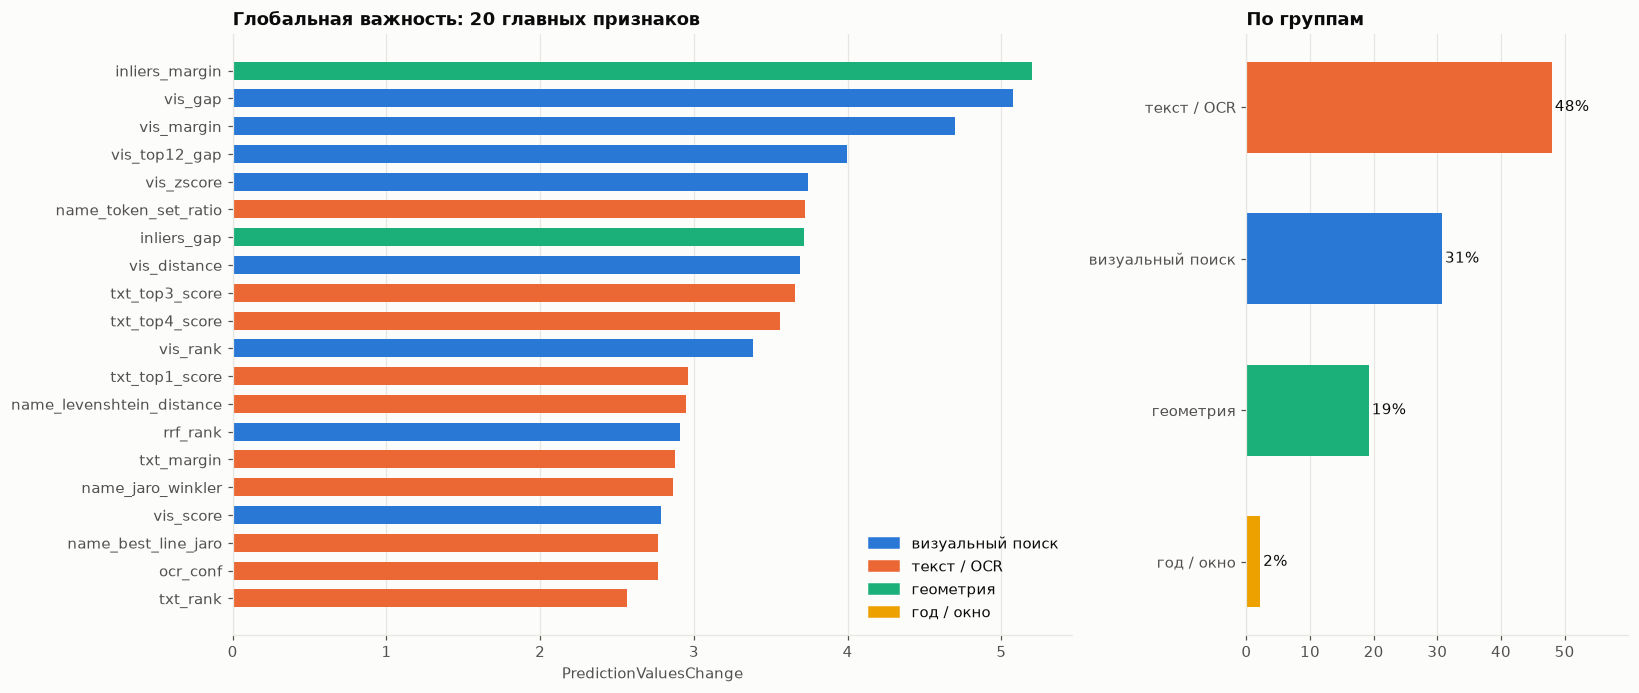

In [11]:
GROUPS = {
    'визуальный поиск': ('vis_', 'rrf_'),
    'текст / OCR': ('txt_', 'ocr_', 'name_', 'winery_', 'disc_', 'color_', 'style_', 'grapes_'),
    'геометрия': ('matches', 'inliers', 'inlier', 'reproj_', 'homography_', 'geometry_'),
    'год / окно': ('vintage_', 'in_window'),
}
GROUP_COLORS = {'визуальный поиск': BLUE, 'текст / OCR': ORANGE, 'геометрия': AQUA,
                'год / окно': YELLOW, 'прочее': VIOLET}


def group_of(name):
    for group, prefixes in GROUPS.items():
        if name.startswith(prefixes):
            return group
    return 'прочее'


global_imp = pd.Series(MODEL.get_feature_importance(), index=NAMES).sort_values()
top = global_imp.tail(20)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15, 6.4), gridspec_kw={'width_ratios': [2.2, 1]})
ax0.barh(top.index, top.values, color=[GROUP_COLORS[group_of(n)] for n in top.index], height=0.65)
ax0.grid(axis='y', visible=False); ax0.set_xlabel('PredictionValuesChange')
ax0.set_title('Глобальная важность: 20 главных признаков')
present = [g for g in GROUP_COLORS if any(group_of(n) == g for n in NAMES)]
handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[g]) for g in present]
ax0.legend(handles, present, loc='lower right')
by_group = global_imp.groupby(global_imp.index.map(group_of)).sum().sort_values()
ax1.barh(by_group.index, by_group.values, color=[GROUP_COLORS[g] for g in by_group.index],
         height=0.6)
for yi, value in enumerate(by_group.values):
    ax1.text(value + 0.5, yi, f'{value:.0f}%', va='center')
ax1.grid(axis='y', visible=False); ax1.set_xlim(0, by_group.max() * 1.25)
ax1.set_title('По группам')
plt.tight_layout(); plt.show()

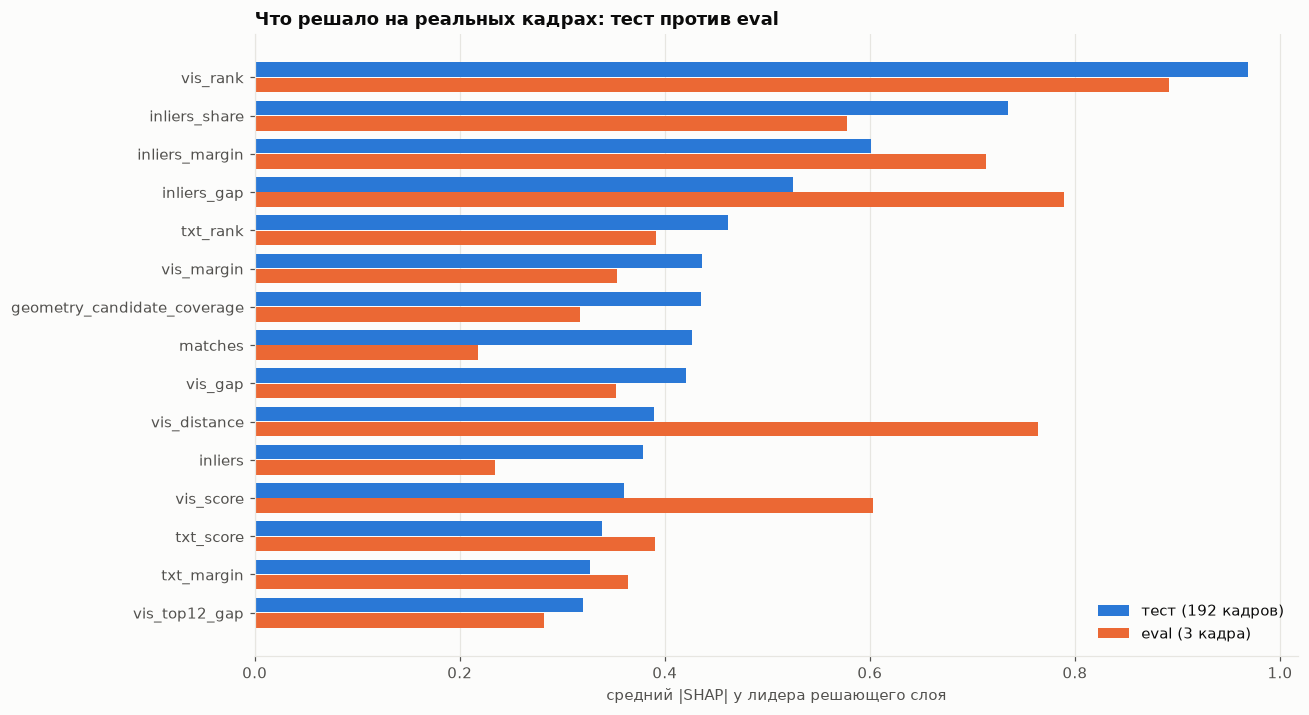

In [12]:
# Лидер самого решающего слоя (максимум логита, до правила семьи и судьи): признаки и SHAP.
leaders = [(r, features_of(r, r['decider_id'])) for r in RECORDS]
leaders = [(r, f) for r, f in leaders if f]
L_matrix, L_shap, _ = shap_rows([f for _, f in leaders])
L = pd.DataFrame({'part': ['eval' if r['source'] == 'eval' else 'тест' for r, _ in leaders],
                  'known': [r['known'] for r, _ in leaders],
                  'correct': [EQ.same(r['true_id'], r['decider_id']) for r, _ in leaders]})
S = pd.DataFrame(np.abs(L_shap), columns=NAMES)

mean_test = S[L.part == 'тест'].mean()
mean_eval = S[L.part == 'eval'].mean()
order = mean_test.sort_values().tail(15).index
fig, ax = plt.subplots(figsize=(12, 6.6))
yy = np.arange(len(order))
n_test, n_eval = (L.part == 'тест').sum(), (L.part == 'eval').sum()
ax.barh(yy + 0.2, mean_test[order], height=0.38, color=BLUE, label=f'тест ({n_test} кадров)')
ax.barh(yy - 0.2, mean_eval[order], height=0.38, color=ORANGE, label=f'eval ({n_eval} кадра)')
ax.set_yticks(yy, order); ax.grid(axis='y', visible=False)
ax.set_xlabel('средний |SHAP| у лидера решающего слоя')
ax.set_title('Что решало на реальных кадрах: тест против eval')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

Направление влияния на тесте: точка — лидер решающего слоя на одном кадре, по горизонтали —
вклад признака в логит, цвет — значение признака (светлый — низкое, тёмный — высокое, в
рангах внутри признака). Например, если тёмные точки справа — чем больше значение, тем
увереннее модель.

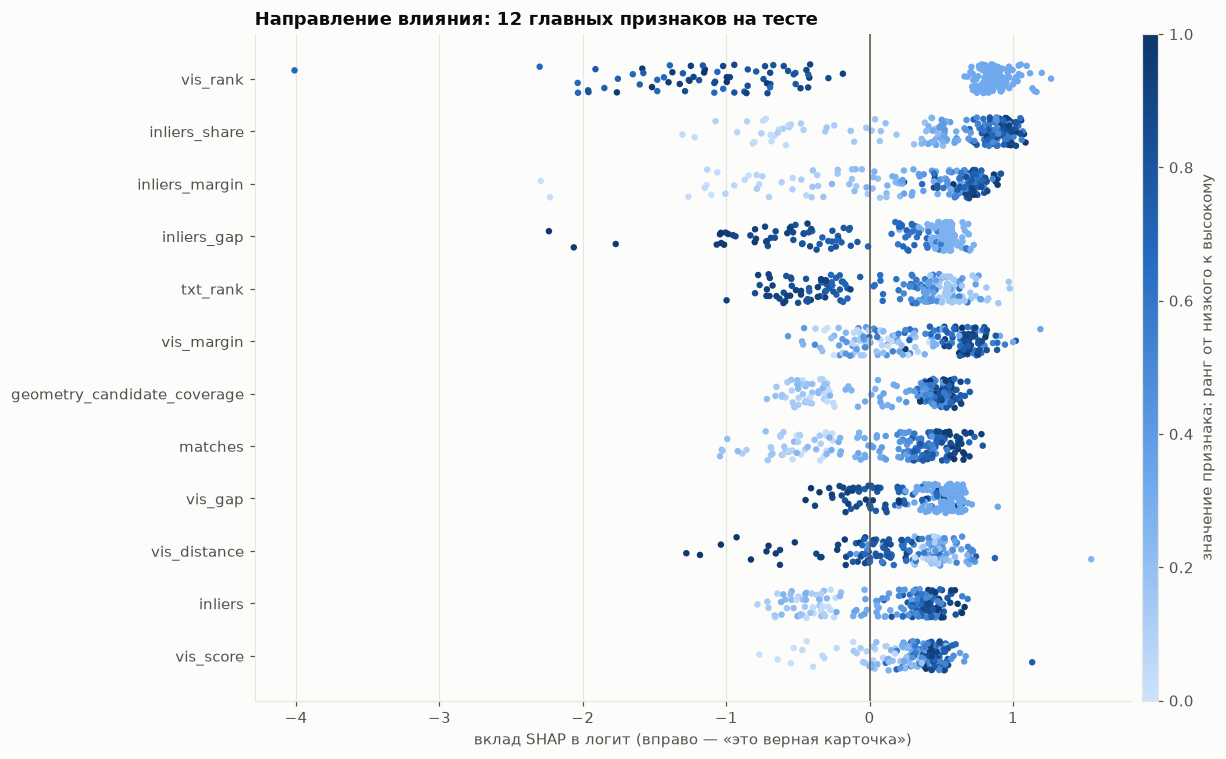

In [13]:
test_mask = (L.part == 'тест').to_numpy()
top_features = mean_test.sort_values(ascending=False).index[:12]
fig, ax = plt.subplots(figsize=(12, 7))
rng = np.random.default_rng(1)
for yi, name in enumerate(top_features[::-1]):
    j = NAMES.index(name)
    values = pd.Series(L_matrix[test_mask, j]).rank(pct=True).to_numpy()
    ax.scatter(L_shap[test_mask, j], yi + rng.uniform(-0.28, 0.28, test_mask.sum()), c=values,
               cmap=SEQ, s=18, edgecolor='none', vmin=0, vmax=1)
ax.set_yticks(range(len(top_features)), top_features[::-1])
ax.axvline(0, color=INK2, linewidth=1); ax.grid(axis='y', visible=False)
ax.set_xlabel('вклад SHAP в логит (вправо — «это верная карточка»)')
ax.set_title('Направление влияния: 12 главных признаков на тесте')
bar = fig.colorbar(plt.cm.ScalarMappable(cmap=SEQ), ax=ax, pad=0.01, aspect=40)
bar.set_label('значение признака: ранг от низкого к высокому')
plt.tight_layout(); plt.show()

### 6.1 Почему решающий слой выбрал неверную карточку

Для каждого знакомого кадра, где лидер решающего слоя неверный, а верная карточка есть среди
кандидатов: разница вкладов SHAP «неверная − верная» по каждому признаку. Красное — признак
тянул к неверной карточке, синее — к верной. Справа — то же, сложенное по группам.

ошибок решающего слоя с верной карточкой среди кандидатов: 10 | из них eval: 1


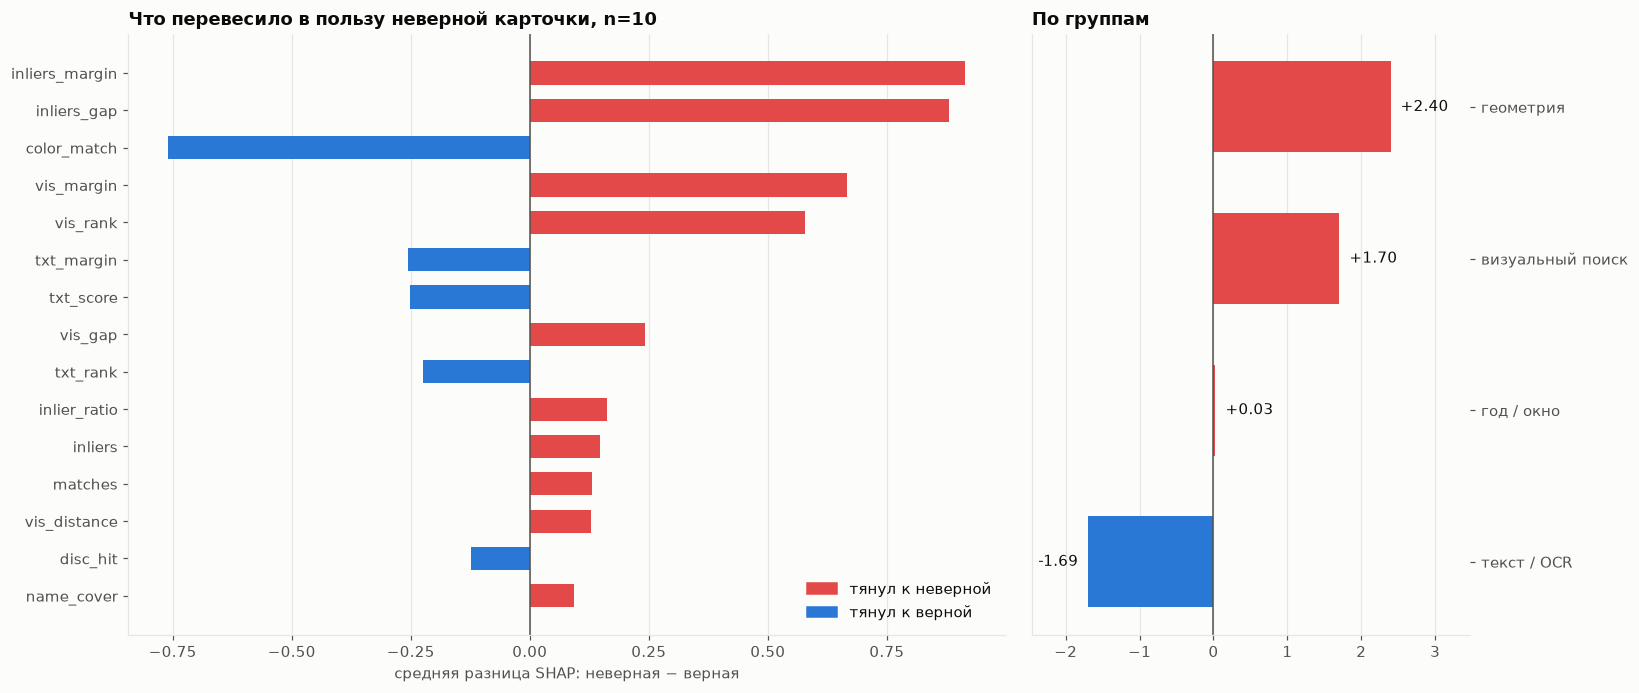

In [14]:
pairs = []
for r in RECORDS:
    if r['known'] and not EQ.same(r['true_id'], r['decider_id']):
        wrong, right = features_of(r, r['decider_id']), features_of(r, r['true_id'])
        if wrong and right:
            pairs.append((r, wrong, right))
print('ошибок решающего слоя с верной карточкой среди кандидатов:', len(pairs),
      '| из них eval:', sum(r['source'] == 'eval' for r, _, _ in pairs))
if pairs:
    _, shap_wrong, _ = shap_rows([w for _, w, _ in pairs])
    _, shap_right, _ = shap_rows([t for _, _, t in pairs])
    delta = pd.DataFrame(shap_wrong - shap_right, columns=NAMES)
    mean_delta = delta.mean()
    order = mean_delta.abs().sort_values().tail(15).index
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15, 6.4), gridspec_kw={'width_ratios': [2, 1]})
    ax0.barh(order, mean_delta[order], color=[NEG if v > 0 else POS for v in mean_delta[order]],
             height=0.62)
    ax0.axvline(0, color=INK2, linewidth=1); ax0.grid(axis='y', visible=False)
    ax0.set_xlabel('средняя разница SHAP: неверная − верная')
    ax0.set_title(f'Что перевесило в пользу неверной карточки, n={len(pairs)}')
    grouped = delta.T.groupby(delta.columns.map(group_of)).sum().T.mean().sort_values()
    ax1.barh(grouped.index, grouped.values, color=[NEG if v > 0 else POS for v in grouped.values],
             height=0.6)
    for yi, value in enumerate(grouped.values):
        ax1.text(value, yi, f'  {value:+.2f}  ', va='center',
                 ha='left' if value >= 0 else 'right')
    span = max(abs(grouped.min()), abs(grouped.max()), 0.1) * 1.45
    ax1.set_xlim(min(grouped.min() * 1.45, -0.1 * span), max(grouped.max() * 1.45, 0.1 * span))
    ax1.axvline(0, color=INK2, linewidth=1); ax1.grid(axis='y', visible=False)
    ax1.set_yticks(range(len(grouped)), grouped.index)
    ax1.yaxis.tick_right()
    ax1.set_title('По группам')
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (NEG, POS)]
    ax0.legend(handles, ['тянул к неверной', 'тянул к верной'], loc='lower right')
    plt.tight_layout(); plt.show()

### 6.2 Доля групп признаков в решении

Сколько от общего |SHAP| лидера приходится на каждую группу: у верных ответов теста, у
ошибок теста и на трёх фото eval. Если у ошибок доля геометрии выше, чем у верных, значит
на ошибках модель полагалась на картинку там, где различали слова.

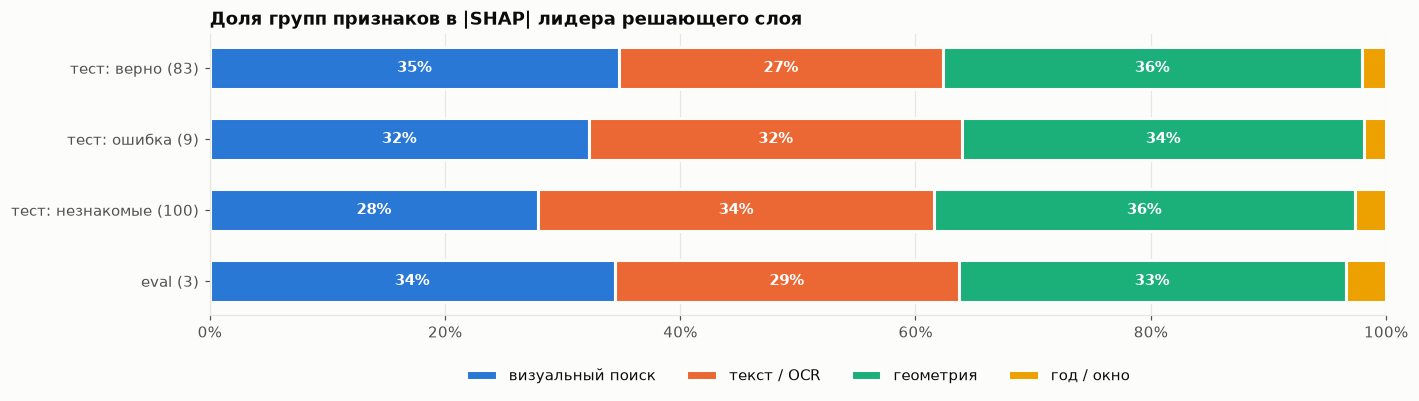

In [15]:
share = S.T.groupby(S.columns.map(group_of)).sum().T
share = share.div(share.sum(axis=1), axis=0)
rows = {
    f'тест: верно ({((L.part == "тест") & L.correct & L.known).sum()})':
        share[(L.part == 'тест') & L.correct & L.known].mean(),
    f'тест: ошибка ({((L.part == "тест") & ~L.correct & L.known).sum()})':
        share[(L.part == 'тест') & ~L.correct & L.known].mean(),
    f'тест: незнакомые ({((L.part == "тест") & ~L.known).sum()})':
        share[(L.part == 'тест') & ~L.known].mean(),
    f'eval ({(L.part == "eval").sum()})': share[L.part == 'eval'].mean(),
}
table = pd.DataFrame(rows).T.fillna(0)
groups = [g for g in GROUP_COLORS if g in table.columns]
fig, ax = plt.subplots(figsize=(13, 3.8))
left = np.zeros(len(table))
y = np.arange(len(table))[::-1]
for group in groups:
    values = table[group].to_numpy()
    ax.barh(y, values, left=left, color=GROUP_COLORS[group], height=0.6, label=group,
            edgecolor=SURFACE, linewidth=2)
    for yi, lv, v in zip(y, left, values):
        if v > 0.07:
            ax.text(lv + v / 2, yi, f'{v:.0%}', ha='center', va='center', color='white',
                    fontweight='bold')
    left += values
ax.set_yticks(y, table.index); ax.set_xlim(0, 1); ax.grid(axis='y', visible=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title('Доля групп признаков в |SHAP| лидера решающего слоя')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=len(groups))
plt.tight_layout(); plt.show()

## 7. Выводы (25.09.2026, судья family-verify со сверкой, инференс `data/derived/nb08`)

**Знакомые вина теста (92 кадра, режим заказчика).** Верная карточка почти всегда рядом:
в длинном списке 92 из 92, в окне геометрии 91. Дальше: решающий слой — 83,
правило семьи — 85, судья — **90 из 92**. Судья исправил 5 кадров и не сломал ни одного.
Вместе с Мускателем из eval это 91 из 93, как в бенчмарке.

**Две оставшиеся ошибки — близнецы одной винодельни:**
- **«Портвейн белый крымский» → «Белый Гурзуф».** Судья прочитал «КРЫМСКИЙ» верно, но
  верной карточки не видел: она шестая в списке, а судье показывают лидера и трёх соседей из
  первой восьмёрки. Кандидат на улучшение (проверять на стенде train): отбирать соседей для
  показа по совпадению с текстом этикетки, а не по месту в списке.
- **«Азюр» Рислинг → «Азюр».** Карточки различаются только сортом, а на лицевой этикетке
  сорта нет. Текстом не решается — нужен контрэтикеточный кадр или визуальные отличия.

**Незнакомые вина (100 кадров, продуктовый порог).** Без судьи ложных приёмов 7 %, с судьёй
37 %. Выбирая карточку, судья поднимает её вероятность до своей уверенности (0.95–1.0),
а «ни одна не подходит» говорит редко. Поэтому он включён только в eval-ручке, где ответ
и так всегда top-1; в `/scan` его нет.

**Три вина eval.**
- **Мускатель белый — верно, но только благодаря судье.** Решающий слой поставил первым
  «Мускат Белый Южнобережный»: у верной карточки `vis_rank = 1` и проигрыш по инлаерам.
  Судья прочитал «МУСКАТЕЛЬ … БЕЛЫЙ» и выбрал верно.
- **Tabiya Пино Нуар и Aristov Donum — вероятность top-1 около 0.01.** Продуктовый режим
  честно отказывает, но eval-ручка всё равно вернёт top-1 slug («Кокуркод»,
  «Аристов Анима Мичела»). Заметно: в каталоге есть и винодельня Табия (Рислинг — №4 в списке),
  и линейка «Аристов» у Кубань-Вино (№1): пайплайн находит соседей по бренду.

**Важность признаков.**
- **Глобально** (PredictionValuesChange) лидирует текст — 48 %, дальше визуальный поиск
  31 % и геометрия 19 %.
- **На реальных кадрах** (|SHAP| лидера) картина другая: геометрия ~36 %, визуальный поиск
  ~35 %, текст ~27 %. Главные признаки — `vis_rank`, `inliers_share`, `inliers_margin`,
  `inliers_gap`. Тест и eval устроены одинаково.
- **На ошибках решающего слоя** (10 кадров) к неверной карточке тянут геометрия (+2.4) и
  визуальный поиск (+1.7), к верной — текст (−1.7), и сильнее всего `color_match`. Близнецов
  одной линейки решающий слой путает, потому что картинка перевешивает слова. Правило семьи
  и судья исправляют это текстом.
- **Что из этого следует:** переобучить решающий слой с парными признаками «против соседки
  по винодельне» (разница `disc_hit`, `color_match`, `grape_match` с сильнейшей соседкой),
  чтобы текст решал внутри линейки уже в модели, а не в правилах после неё. Проверять — OOF
  на train.

**Оговорка о честности теста.** Ошибку в сверке судьи (при опровергнутом выборе цвет и
сладость не считались подтверждением соседки) я нашла на двух тестовых кадрах Цимлянского.
Исправление проверено на стенде train: 89 из 91, стресс 71 из 85, 5 замен из 5 верные.
Но для этих двух кадров тест больше не независим: 90 из 92 здесь немного оптимистичнее, чем
была бы слепая проверка.